<a href="https://colab.research.google.com/github/Tawhidrahman292/Roadmap-Docs/blob/main/Skill_Morph_ML_Regression_Classification_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression & Classification with Machine Learning

**Topics:** Linear Regression, Logistic Regression, Support Vector Machine (SVM)

**Instructor:** Md. Samiul Islam  
**Organization:** Skill Morph Research Lab

## 1. Setup and Import Libraries

In [24]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix

print("Libraries imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully!


## 2. Load and Explore Dataset
Loading the Housing dataset and checking basic information.

In [25]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets/Housing.csv')

# Display first few rows
print("First 5 rows:")
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 54

In [34]:
df["price_per_area"] = df["price"] / df["area"]
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_area
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,1792.452830
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,1367.187500
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,1229.919679
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,1628.666667
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,1537.735849


## 3. Data Preprocessing
Converting categorical variables and handling missing values.

In [26]:
# Drop any missing values
df = df.dropna()

# Convert yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert furnishingstatus to numeric
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

print("Data preprocessing completed!")
print(df.head())

Data preprocessing completed!
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 

## 4. Feature Selection and Target Definition
Selecting features (X) and target variable (y) for modeling.

In [27]:
# Select features
X = df.drop('price', axis=1)

# Target for Linear Regression (continuous price)
y_regression = df['price']

# Target for Classification (binary: 1 if price > median, 0 otherwise)
median_price = df['price'].median()
y_classification = (df['price'] > median_price).astype(int)

print(f"Features shape: {X.shape}")
print(f"Regression target shape: {y_regression.shape}")
print(f"Classification target distribution:\n{y_classification.value_counts()}")

Features shape: (545, 12)
Regression target shape: (545,)
Classification target distribution:
price
0    275
1    270
Name: count, dtype: int64


## 5. Train-Test Split
Splitting data into 70% training and 30% testing sets.

In [28]:
# Split for Linear Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.3, random_state=42
)

# Split for Classification (Logistic Regression & SVM)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.3, random_state=42
)

print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Testing set size: {X_test_reg.shape[0]}")

Training set size: 381
Testing set size: 164


## 6. Linear Regression
Predicting continuous house prices.

In [ ]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_lr = lr_model.predict(X_test_reg)

# Evaluate
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))

print("Linear Regression Results:")
print(f"Mean Absolute Error (MAE): {mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:,.2f}")

Linear Regression Results:
Mean Absolute Error (MAE): 925,543.55
Root Mean Squared Error (RMSE): 1,238,970.44


## 7. Logistic Regression
Classifying houses as high-priced or low-priced.

In [30]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_log = log_model.predict(X_test_clf)

# Evaluate
acc_log = accuracy_score(y_test_clf, y_pred_log)
cm_log = confusion_matrix(y_test_clf, y_pred_log)

print("Logistic Regression Results:")
print(f"Accuracy: {acc_log:.4f}")
print(f"\nConfusion Matrix:\n{cm_log}")

Logistic Regression Results:
Accuracy: 0.8232

Confusion Matrix:
[[72 14]
 [15 63]]


## 8. Support Vector Machine (SVM)
Using SVM with linear kernel for classification.

In [31]:
# Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_svm = svm_model.predict(X_test_clf)

# Evaluate
acc_svm = accuracy_score(y_test_clf, y_pred_svm)
cm_svm = confusion_matrix(y_test_clf, y_pred_svm)

print("SVM Results:")
print(f"Accuracy: {acc_svm:.4f}")
print(f"\nConfusion Matrix:\n{cm_svm}")

SVM Results:
Accuracy: 0.7866

Confusion Matrix:
[[65 21]
 [14 64]]


## 9. Visualizations

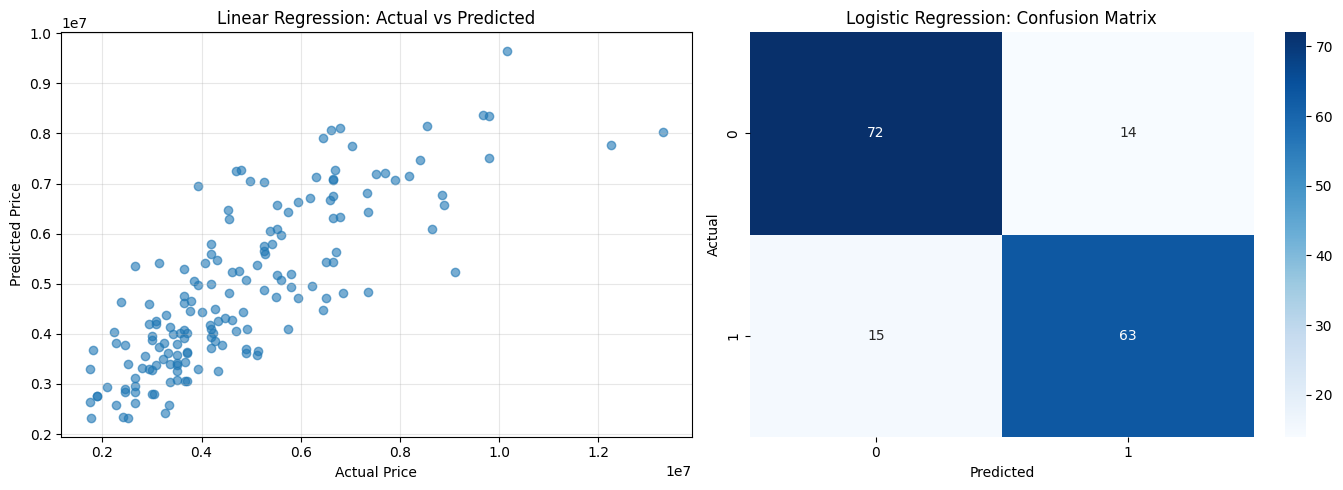

In [32]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (Linear Regression)
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.6)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix (Logistic Regression)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Logistic Regression: Confusion Matrix')

plt.tight_layout()
plt.show()

## 10. Model Comparison Summary

In [33]:
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print("\n1. LINEAR REGRESSION (Regression Task)")
print(f"   - MAE: {mae_lr:,.2f}")
print(f"   - RMSE: {rmse_lr:,.2f}")
print(f"   - Use when: Predicting continuous values\n")

print("2. LOGISTIC REGRESSION (Classification Task)")
print(f"   - Accuracy: {acc_log:.4f}")
print(f"   - Use when: Binary classification with linear boundaries\n")

print("3. SUPPORT VECTOR MACHINE (Classification Task)")
print(f"   - Accuracy: {acc_svm:.4f}")
print(f"   - Use when: Complex decision boundaries needed")
print("="*60)

MODEL COMPARISON SUMMARY

1. LINEAR REGRESSION (Regression Task)
   - MAE: 925,543.55
   - RMSE: 1,238,970.44
   - Use when: Predicting continuous values

2. LOGISTIC REGRESSION (Classification Task)
   - Accuracy: 0.8232
   - Use when: Binary classification with linear boundaries

3. SUPPORT VECTOR MACHINE (Classification Task)
   - Accuracy: 0.7866
   - Use when: Complex decision boundaries needed


## Assignment

Complete the following tasks to practice and improve your understanding:

**Task 1:** Change the train-test split ratio to 70-30 and report the performance metrics for all three models.

**Task 2:** Add one new feature to the dataset (e.g., price per square foot = price/area) and observe how model performance changes.